In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import json 
import warnings
import os
import re

def arima_estimator(data, N_remove, N_estimate, link, normalize_data=True, save_figures=False, save_path=None, show_figs=False):
    print(f'Estimating for link {link}')
    warnings.filterwarnings("ignore")
    # Data preparation (use only the 'Error' column for ARIMA)
    dates = data['Date']
    target_column = 'Error'
    data_values = data[target_column].values
    
    if normalize_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_values = scaler.fit_transform(data[target_column].values.reshape(-1, 1)).flatten()
    else:
        data_values = data[target_column].values

    # Split the data into past and future
    if N_remove == 0:
        past_data_values = data_values
        last_date = dates.iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]
    else:
        past_data_values = data_values[:-N_remove]
        future_data_values = data_values[-N_remove:]
        last_date = dates.iloc[-N_remove - 1]
        future_dates = pd.date_range(start=dates.iloc[-N_remove], periods=N_estimate + 1, freq='D')[1:]
    
    # Train ARIMA model on past data
    p, d, q = 60, 2, 1 # These are parameters of the ARIMA model, can be adjusted
    arima_model = ARIMA(past_data_values, order=(p, d, q))
    arima_model_fit = arima_model.fit()

    # Predict both past data and future data
    y_train_pred = arima_model_fit.predict(start=0, end=len(past_data_values)-1)
    future_predictions = arima_model_fit.forecast(steps=N_estimate)

    # Inverse transform if data was normalized
    if normalize_data:
        y_train_pred = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()
        future_predictions = scaler.inverse_transform(future_predictions.reshape(-1, 1)).flatten()
        past_data_values = scaler.inverse_transform(past_data_values.reshape(-1, 1)).flatten()
        if N_remove != 0:
            future_data_values = scaler.inverse_transform(future_data_values.reshape(-1, 1)).flatten()

    # Error metrics for training data
    error_of_train_estimation = np.abs(past_data_values - y_train_pred)
    mean_error_train_estimation = np.mean(error_of_train_estimation)
    std_error_train_estimation = np.std(error_of_train_estimation)
    rmse_error_train_estimation = np.sqrt(mean_squared_error(past_data_values, y_train_pred))

    # If we have future data, calculate error metrics for future predictions
    if N_remove != 0:
        error_of_future_estimation = np.abs(future_data_values - future_predictions)
        mean_error_future_estimation = np.mean(error_of_future_estimation)
        std_error_future_estimation = np.std(error_of_future_estimation)
        rmse_error_future_estimation = np.sqrt(mean_squared_error(future_data_values, future_predictions))
    else:
        error_of_future_estimation = mean_error_future_estimation = std_error_future_estimation = rmse_error_future_estimation = None

    result = {
        link: {
            "Normalized_data": normalize_data,

            "Complete_dates": pd.concat([dates, pd.Series(future_dates)]),
            "Complete_data": np.concatenate([past_data_values, future_data_values]).tolist(),
            "Past_data": past_data_values.tolist(),
            "Past_dates": dates[:-N_remove],

            "Train_dates": dates[:-N_remove],
            "Last_train_date": last_date,
            "Train_data": past_data_values.tolist(),
            "Train_estimated_data": y_train_pred.tolist(),

            "Train_estimation_error": error_of_train_estimation.tolist(),
            "Train_mean_estimation_error": mean_error_train_estimation,
            "Train_std_estimation_error": std_error_train_estimation,
            "Train_rmse_estimation_error": rmse_error_train_estimation,

            "Test_dates": future_dates,
            "Test_data": future_data_values.tolist(),
            "Test_estimated_data": future_predictions.tolist(),

            # Future error metrics
            "Test_estimation_error": error_of_future_estimation.tolist(),
            "Test_mean_estimation_error": mean_error_future_estimation,
            "Test_std_estimation_error": std_error_future_estimation,
            "Test_rmse_estimation_error": rmse_error_future_estimation,
        }
    }


    if show_figs or save_figures:
        plt.figure(figsize=(18, 30))

        # Calculate the common Y-axis limits
        all_data = np.concatenate([
            result[link]['Train_data'],
            result[link]['Train_estimated_data'],
            result[link]['Test_data'],
            result[link]['Test_estimated_data'],
            np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'],
            np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'],
            result[link]['Test_estimation_error']
        ])

        y_min, y_max = np.min(all_data), np.max(all_data)

        # Train data plot
        plt.subplot(4, 1, 1)
        plt.plot(result[link]['Test_dates'], result[link]['Test_data'], label='Actual Data', color='royalblue',  marker='o')
        plt.plot(result[link]['Test_dates'], result[link]['Test_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--',  marker='x')
        plt.title(f'ARIMA\nActual vs Estimated Data')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(0.0, 0.015)  # Set common Y-axis limits

        # Test data plot
        plt.subplot(4, 1, 2)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], result[link]['Test_estimation_error'], label='Error of the Estimation', color='green', marker='o')
        plt.axhline(result[link]['Test_mean_estimation_error'], linestyle='dashed', label='Average Estimation Error', color='purple')
        plt.axhline(result[link]['Test_rmse_estimation_error'], linestyle='dashed', label='Root Mean Squared Error', color='deeppink')
        plt.title(f'Actual vs Estimated Data   RMSE: {result[link]["Test_rmse_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(0.0, 0.015)  # Set common Y-axis limits

        # Upper and lower bounds for test data
        plt.subplot(4, 1, 3)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'], label='Upper Data Bound', color='teal', marker='o')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'], label='Lower Data Bound', color='orchid', marker='o')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--', marker='x')
        plt.title(f'Bounds of Actual vs Estimated Data    std: {result[link]["Test_std_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(0.0, 0.015)  # Set common Y-axis limits
    
        plt.tight_layout()
        if save_figures:
            plt.savefig(save_path)
            plt.close()
        
        if show_figs: 
            plt.show()
    

    result[link]["Train_dates"] = result[link]["Train_dates"].to_list()
    result[link]["Test_dates"] = result[link]["Test_dates"].to_list()
    result[link]["Past_dates"] = result[link]["Past_dates"].to_list()
    
    for key in result:
        result[key]['Complete_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Complete_dates']]
        result[key]['Train_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Train_dates']]
        result[key]['Test_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Test_dates']]
        result[key]['Past_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Past_dates']]
        result[key]['Last_train_date'] = result[key]['Last_train_date'].strftime('%Y-%m-%d')

    with open(f"rebuttal/arima_res_{link}.json", "w") as outfile: 
        json.dump(result, outfile)

    return result


In [27]:
def get_graphs(link): 
    # Load the JSON file
    file_path = f"rebuttal/arima_res_{link}.json"
    with open(file_path, "r") as file:
        data = json.load(file)

    # Extract Train_data and Test_data
    train_data = data[link]["Train_data"]
    test_data = data[link]["Test_data"]  # Using Test_data as per request

    # Compute the average of Train_data
    train_data_avg = sum(train_data) / len(train_data)

    # Subtract train_data_avg from each value in Test_data
    adjusted_test_data = [abs(value - train_data_avg) for value in test_data]

    mean_mean = sum(adjusted_test_data)/len(adjusted_test_data)

    # Compute estimation_error: Test_estimated_data - Test_estimation_error
    test_estimated_data = data[link]["Test_estimated_data"]
    estimation_error = data[link]["Test_estimation_error"]
    mean_estimation_error = data[link]["Test_mean_estimation_error"]

    improvement = mean_estimation_error - mean_mean

    # Generate x-axis labels
    days = [f"Day {i+1}" for i in range(len(test_data))]
    
    # Plot the data
    plt.figure(figsize=(12, 6))

    #Data (marker: o, linestyle:--)
    plt.plot(days, test_data, label='Actual Data', color='royalblue',  marker='o')
    plt.plot(days, test_estimated_data, label='Estimated Data (ARIMA)', color='darkorange', linestyle='--',  marker='o')
    plt.axhline(y=train_data_avg, label="Train Data Avg", color='green', linestyle='--')

    #Error
    plt.plot(days, estimation_error, label="Error of the Estimation", linestyle="-.", color='darkorange', marker='x')
    plt.plot(days, adjusted_test_data, label="Error of the Average", linestyle="-.", color='green', marker='x')

    plt.axhline(y=mean_estimation_error, color='darkorange', linestyle="-.", label="Mean of the Estimation Error")
    plt.axhline(y=mean_mean, color='green', linestyle="-.", label="Mean of the Average Error")

    plt.xlabel("Days")
    plt.ylabel("Errors")
    plt.title("Error Analysis of Test Data vs Estimated Data")
    plt.xticks(rotation=45, fontsize=8)
    plt.legend()
    plt.grid(True)

    plt.savefig(f'rebuttal/figs/arima_{link}')
    plt.close()
    # Show plot
    # plt.show()
    
    return [link, mean_mean, mean_estimation_error, improvement]


In [28]:
pattern = r'_(\d{1,3}-\d{1,3})\.xlsx'

# files_in_dir = os.listdir('./LauraHandy/data/not_normalized/Brisbane/up_to_15-07-2024')
files_in_dir = os.listdir('C:/Users/lrodsor1.UPVNET/OneDrive - UPV/Documentos/Code/error_estimation/LauraHandy/data/not_normalized/Brisbane/up_to_15-07-2024')
# C:\Users\lrodsor1.UPVNET\OneDrive - UPV\Documentos\Code\error_estimation\LauraHandy\data\not_normalized\Brisbane\up_to_15-07-2024

df = pd.DataFrame(columns=['Link', 'Error_avg', 'Error_estimation', 'Improvement'])

data_files = []
for file_name in files_in_dir:
    data_files.append('C:/Users/lrodsor1.UPVNET/OneDrive - UPV/Documentos/Code/error_estimation/LauraHandy/data/not_normalized/Brisbane/up_to_15-07-2024/' + file_name)

for file_path in data_files:
    data = pd.read_excel(file_path)
    link = re.search(pattern, file_path).group(1)
    arima_estimator(data, 30, 30, link, normalize_data=True, save_figures=False, save_path=None, show_figs=False)
    result = get_graphs(link)
    print(result)
    df.loc[len(df)] = result
df.to_csv('rebuttal/estimation_improvement.csv', index=False)


Estimating for link 0-1
['0-1', 0.002315672244047893, 0.003170423998157938, 0.0008547517541100452]
Estimating for link 0-14
['0-14', 0.001733507565757523, 0.0016884478292824895, -4.505973647503359e-05]
Estimating for link 1-2
['1-2', 0.0037264134823199436, 0.004902613099851604, 0.00117619961753166]
Estimating for link 10-11
['10-11', 0.0015238363753864391, 0.004028959888569207, 0.002505123513182768]
Estimating for link 10-9
['10-9', 0.002819456343093439, 0.003999906721063371, 0.0011804503779699314]
Estimating for link 100-101
['100-101', 0.002889149965866716, 0.0021016113378299704, -0.0007875386280367458]
Estimating for link 100-110
['100-110', 0.0087449709557074, 0.00962636301943567, 0.0008813920637282709]
Estimating for link 100-99
['100-99', 0.004203243828173056, 0.004117403723443898, -8.584010472915786e-05]
Estimating for link 101-102
['101-102', 0.0017778602596131472, 0.003611972348686781, 0.0018341120890736338]
Estimating for link 102-103
['102-103', 0.0023403281808199185, 0.0038

Estimating for link 104-105


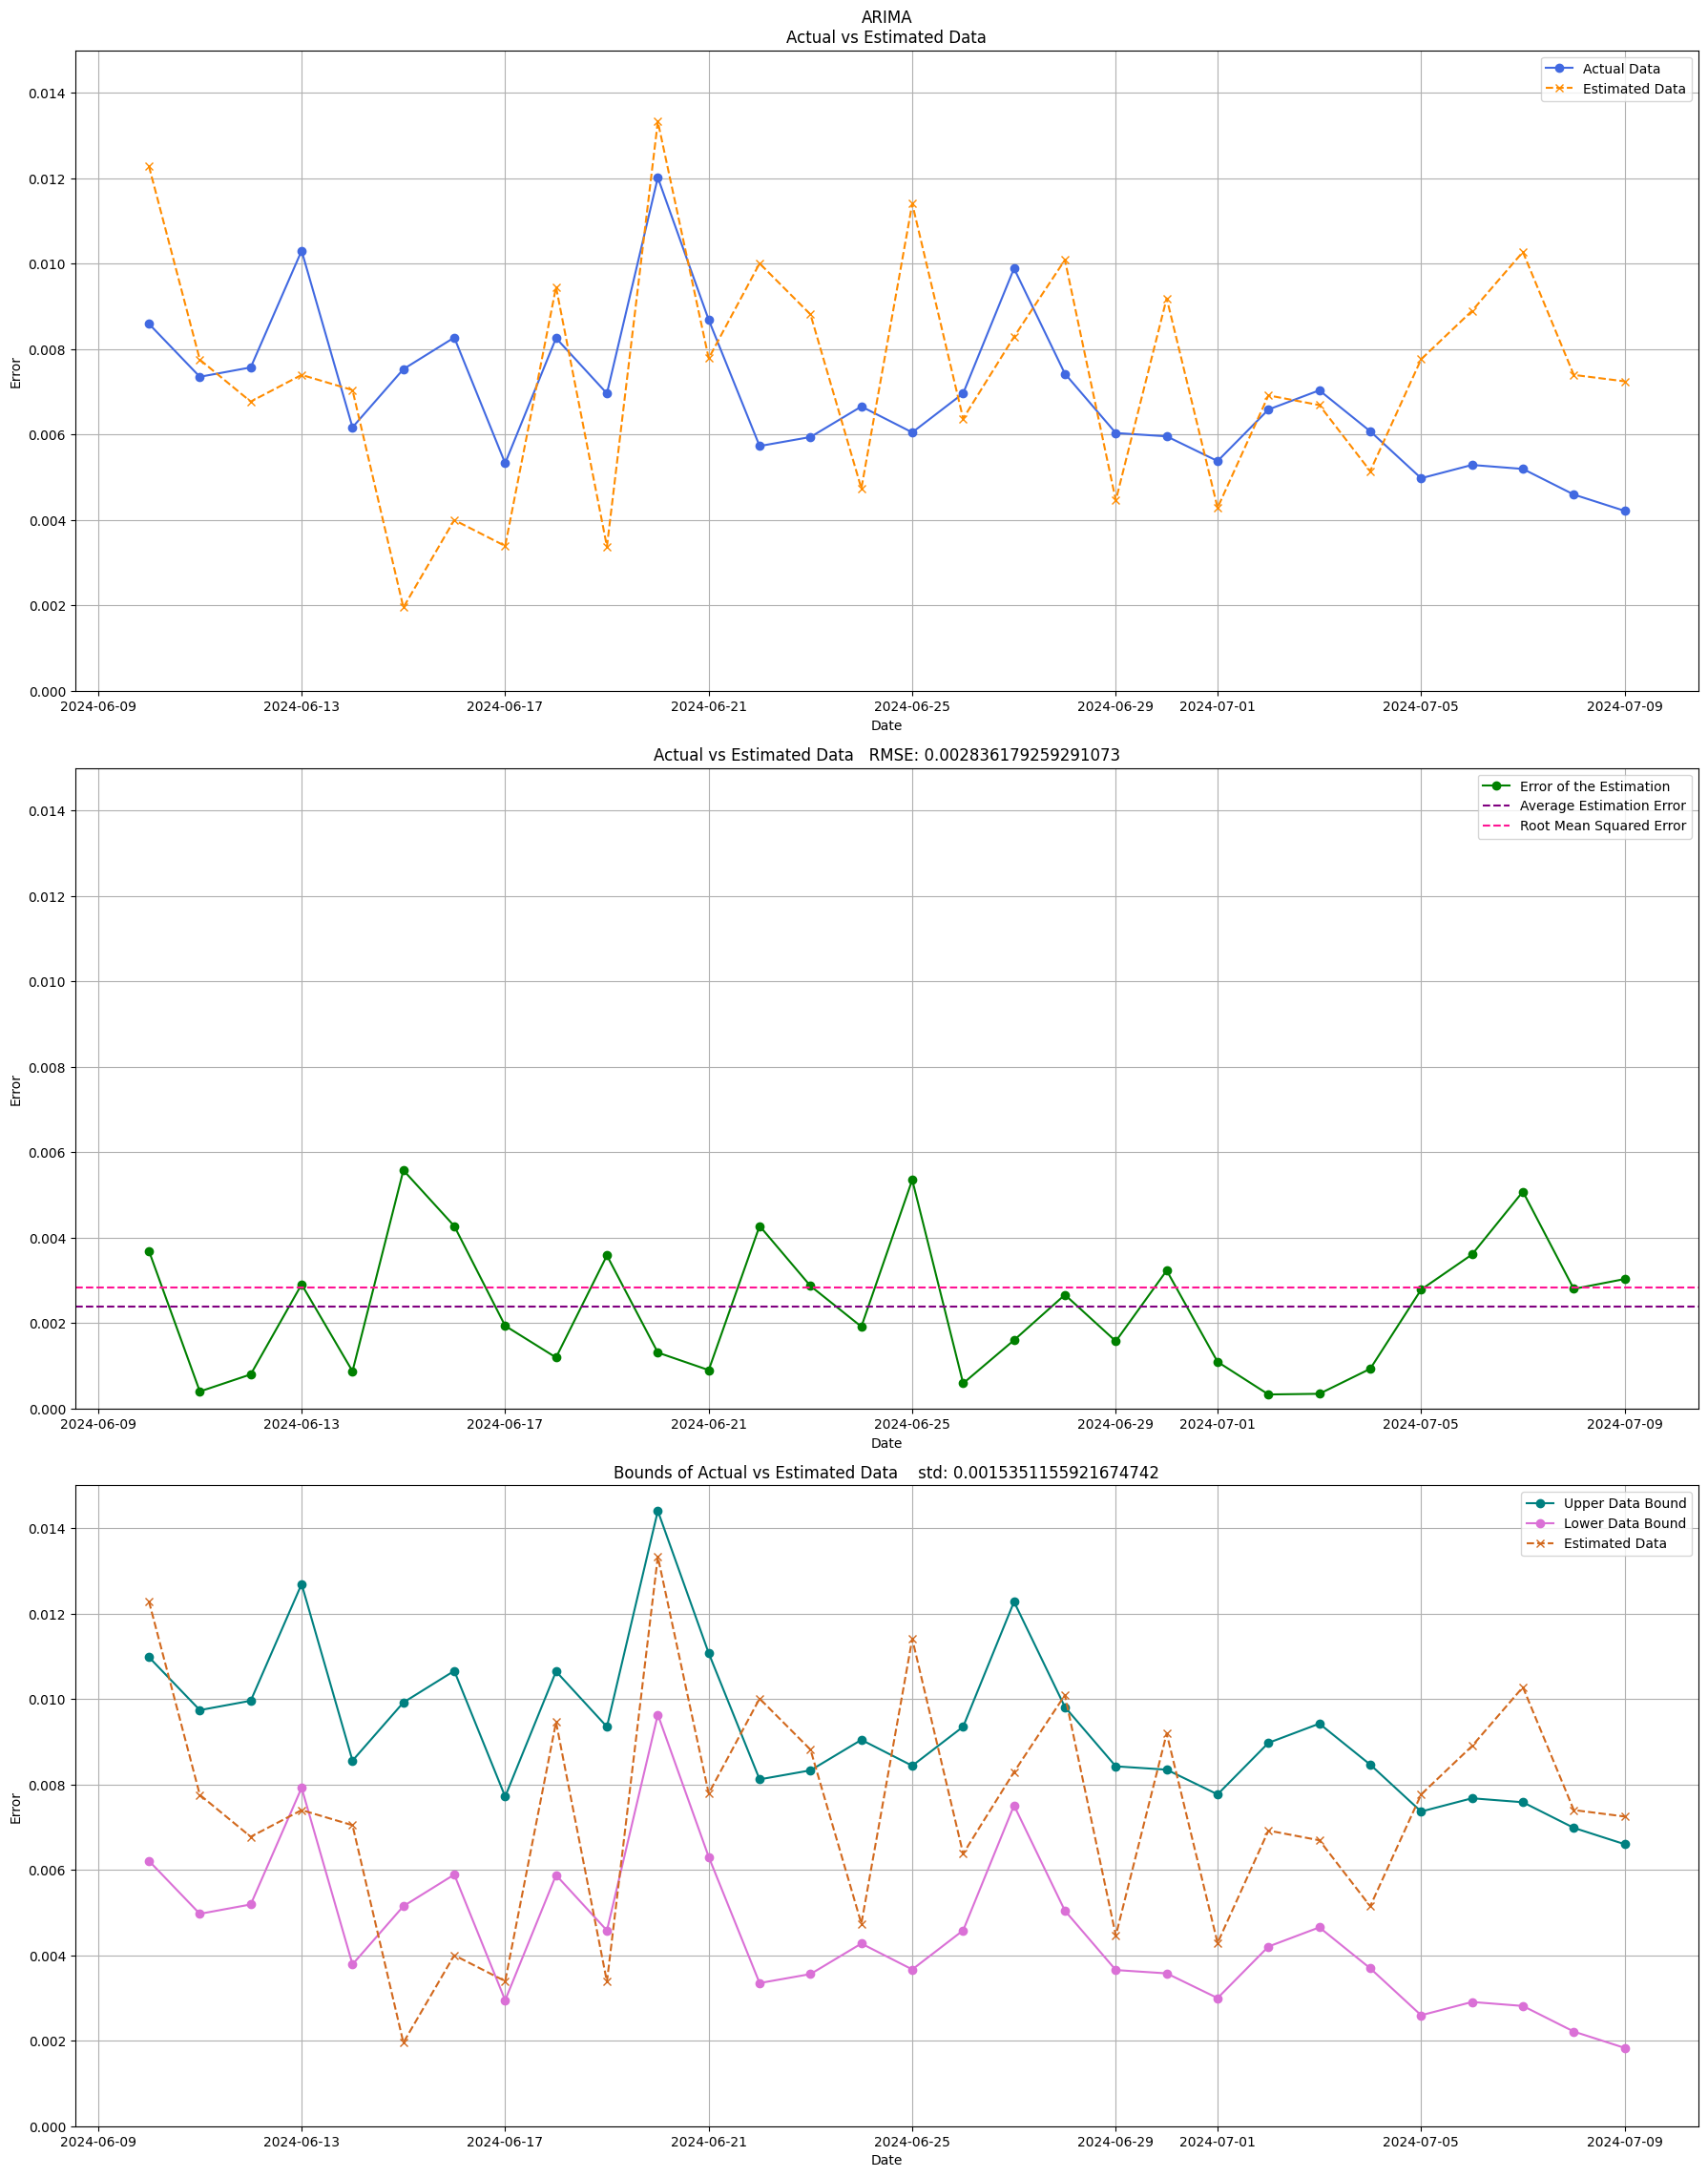

{'104-105': {'Normalized_data': True,
  'Complete_dates': ['2023-10-31',
   '2023-11-01',
   '2023-11-02',
   '2023-11-03',
   '2023-11-04',
   '2023-11-05',
   '2023-11-06',
   '2023-11-07',
   '2023-11-08',
   '2023-11-09',
   '2023-11-10',
   '2023-11-11',
   '2023-11-12',
   '2023-11-13',
   '2023-11-14',
   '2023-11-15',
   '2023-11-16',
   '2023-11-17',
   '2023-11-18',
   '2023-11-19',
   '2023-11-20',
   '2023-11-21',
   '2023-11-22',
   '2023-11-23',
   '2023-11-24',
   '2023-11-25',
   '2023-11-26',
   '2023-11-27',
   '2023-11-28',
   '2023-11-29',
   '2023-11-30',
   '2023-12-01',
   '2023-12-02',
   '2023-12-03',
   '2023-12-04',
   '2023-12-05',
   '2023-12-06',
   '2023-12-07',
   '2023-12-08',
   '2023-12-09',
   '2023-12-10',
   '2023-12-11',
   '2023-12-12',
   '2023-12-13',
   '2023-12-14',
   '2023-12-15',
   '2023-12-16',
   '2023-12-17',
   '2023-12-18',
   '2023-12-19',
   '2023-12-20',
   '2023-12-21',
   '2023-12-22',
   '2023-12-23',
   '2023-12-24',
   '2023-

In [31]:
file_path = 'up_to_15-07-2024/brisbane_104-105.xlsx'  # Update this path to the correct location of your Excel file
df = pd.read_excel(file_path)
arima_estimator(df, 30, 30, '104-105', normalize_data=True, save_figures=False, save_path=None, show_figs=True)